# 망고 라벨 데이터 시각화

`labels_parsed.csv`를 이용해 클래스 분포, 데이터 분할, 검토 상태, YOLO 바운딩박스의 크기와 위치를 살펴봅니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

CSV_PATH = Path("/Users/min_youngjune/Library/Mobile Documents/com~apple~CloudDocs/부트캠프/최종프로젝트/labels_parsed.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df["bbox_area"] = df["width_clean"].mul(df["height_clean"])

print(f"행 수: {len(df):,}개 | 이미지 수: {df['image_name'].nunique():,}장")
display(df.head())


행 수: 2,145개 | 이미지 수: 1,286장


,split,image_name,label_file,line_no,class_id,class_name,x_center,y_center,width,height,issue_type,action,reviewer,note,dataset_action,x_center_clean,y_center_clean,width_clean,height_clean,bbox_area
0,test,Alternaria (110),Alternaria (110).txt,1,0,Alternaria,0.279825,0.378547,0.338071,0.495839,none,keep,윤원택,NaN,include,0.279825,0.378547,0.338071,0.495839,0.167629
1,test,Alternaria (12),Alternaria (12).txt,1,0,Alternaria,0.412942,0.703472,0.359204,0.537159,none,keep,윤원택,NaN,exclude,NaN,NaN,NaN,NaN,NaN
2,test,Alternaria (145),Alternaria (145).txt,1,0,Alternaria,0.447338,0.618924,0.668403,0.603299,none,keep,윤원택,NaN,include,0.447338,0.618924,0.668403,0.603299,0.403247
3,test,Alternaria (145),Alternaria (145).txt,2,0,Alternaria,0.759115,0.181424,0.481771,0.362847,none,keep,윤원택,NaN,include,0.759115,0.181424,0.481771,0.362847,0.174809
4,test,Alternaria (145),Alternaria (145).txt,3,0,Alternaria,0.789497,0.756293,0.421007,0.487413,none,keep,윤원택,NaN,include,0.789497,0.756293,0.421007,0.487413,0.205204


## 1. 데이터 기본 요약

클래스와 데이터 분할별 라벨 수를 확인합니다.

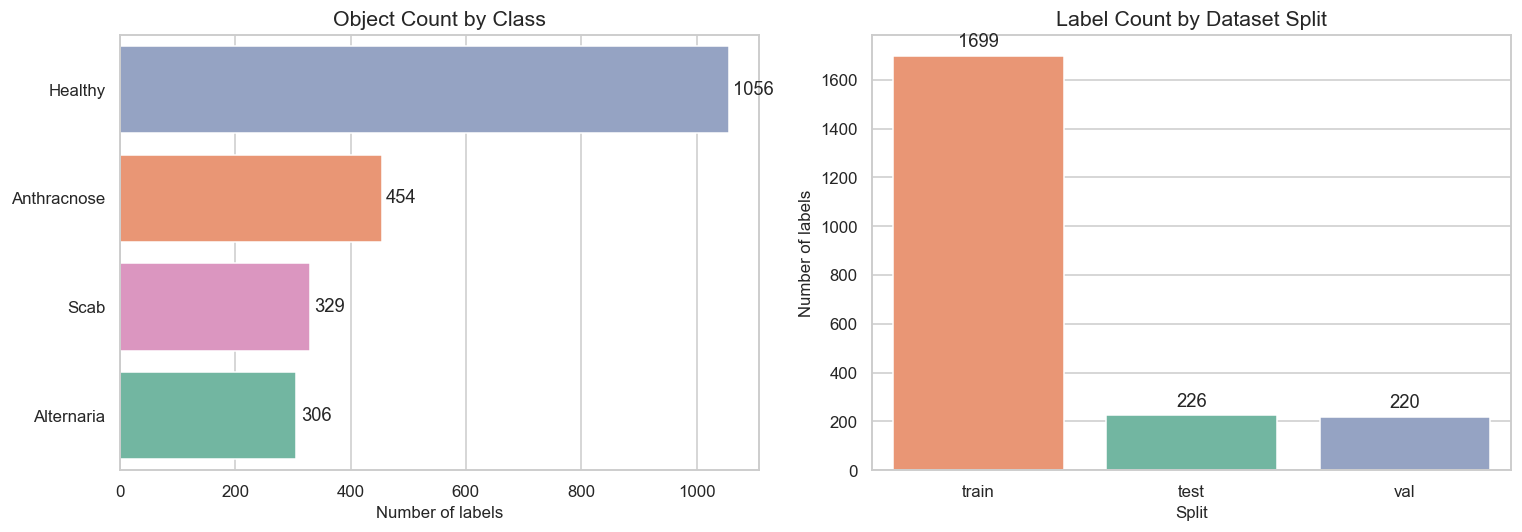

class_name,Alternaria,Anthracnose,Healthy,Scab,All
split,,,,,
test,37,58,85,46,226
train,242,345,859,253,1699
val,27,51,112,30,220
All,306,454,1056,329,2145


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = df["class_name"].value_counts().index
sns.countplot(data=df, y="class_name", order=class_order, ax=axes[0], hue="class_name", legend=False)
axes[0].set_title("Object Count by Class")
axes[0].set_xlabel("Number of labels")
axes[0].set_ylabel("")

split_order = df["split"].value_counts().index
sns.countplot(data=df, x="split", order=split_order, ax=axes[1], hue="split", legend=False)
axes[1].set_title("Label Count by Dataset Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Number of labels")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

display(pd.crosstab(df["split"], df["class_name"], margins=True))


## 2. 검토 및 데이터 처리 상태

라벨 검토 결과와 데이터셋 포함 여부를 비교해 품질관리 대상이 어디에 집중되어 있는지 확인합니다.

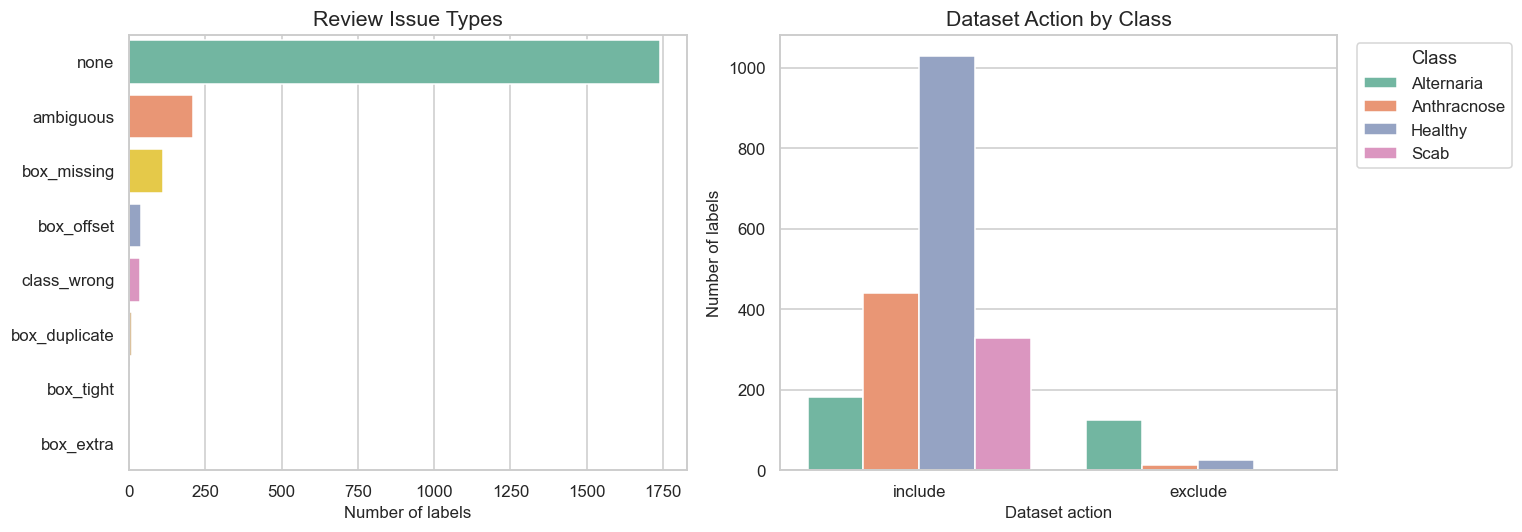

dataset_action,exclude,include,All
issue_type,,,
ambiguous,32,177,209
box_duplicate,8,1,9
box_extra,1,0,1
box_missing,0,110,110
box_offset,0,39,39
box_tight,0,1,1
class_wrong,3,31,34
none,120,1622,1742
All,164,1981,2145


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

issue_order = df["issue_type"].value_counts().index
sns.countplot(data=df, y="issue_type", order=issue_order, ax=axes[0], hue="issue_type", legend=False)
axes[0].set_title("Review Issue Types")
axes[0].set_xlabel("Number of labels")
axes[0].set_ylabel("")

sns.countplot(data=df, x="dataset_action", hue="class_name", ax=axes[1])
axes[1].set_title("Dataset Action by Class")
axes[1].set_xlabel("Dataset action")
axes[1].set_ylabel("Number of labels")
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

display(pd.crosstab(df["issue_type"], df["dataset_action"], margins=True))


## 3. YOLO 바운딩박스 분포

정제된 좌표를 기준으로 객체 크기와 이미지 안에서의 위치를 확인합니다. 좌표와 크기는 YOLO 정규화 값이므로 모두 0~1 범위입니다.

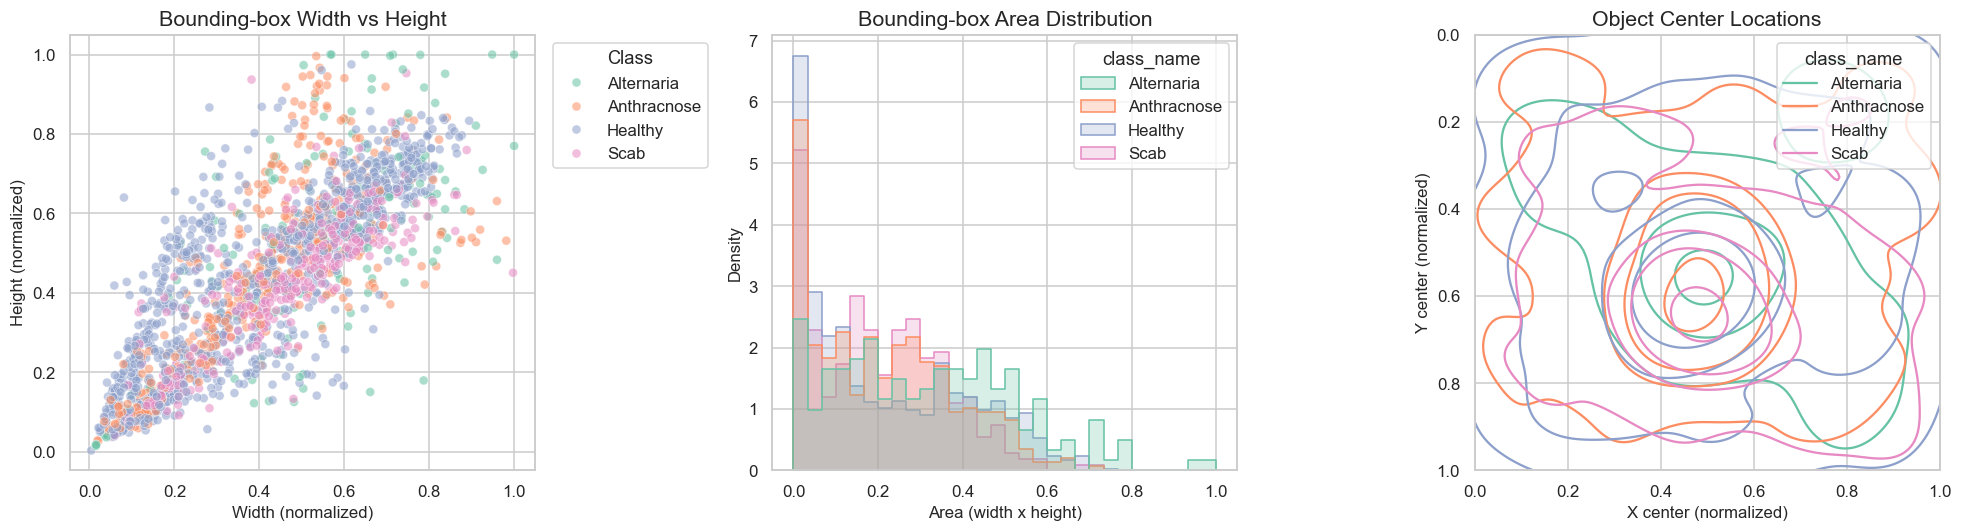

width_clean               height_clean               bbox_area  \
                  count median   mean        count median   mean     count   
class_name                                                                   
Alternaria          182  0.555  0.534          182  0.554  0.531       182   
Anthracnose         441  0.422  0.403          441  0.443  0.439       441   
Healthy            1030  0.390  0.398         1030  0.462  0.429      1030   
Scab                328  0.462  0.435          328  0.428  0.401       328   

                           
            median   mean  
class_name                 
Alternaria   0.311  0.321  
Anthracnose  0.196  0.214  
Healthy      0.155  0.215  
Scab         0.197  0.206

In [4]:
plot_df = df.dropna(subset=["x_center_clean", "y_center_clean", "width_clean", "height_clean"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=plot_df,
    x="width_clean",
    y="height_clean",
    hue="class_name",
    alpha=0.55,
    s=35,
    ax=axes[0],
)
axes[0].set_title("Bounding-box Width vs Height")
axes[0].set_xlabel("Width (normalized)")
axes[0].set_ylabel("Height (normalized)")
axes[0].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.histplot(
    data=plot_df,
    x="bbox_area",
    hue="class_name",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Bounding-box Area Distribution")
axes[1].set_xlabel("Area (width x height)")
axes[1].set_ylabel("Density")

sns.kdeplot(
    data=plot_df,
    x="x_center_clean",
    y="y_center_clean",
    hue="class_name",
    fill=False,
    levels=5,
    thresh=0.05,
    ax=axes[2],
)
axes[2].set_title("Object Center Locations")
axes[2].set_xlabel("X center (normalized)")
axes[2].set_ylabel("Y center (normalized)")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

summary = plot_df.groupby("class_name")[["width_clean", "height_clean", "bbox_area"]].agg(["count", "median", "mean"])
display(summary.round(3))
